## Using the Wine dataset to demonstrate the use of SVMs

In [43]:
# import libraries
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [44]:
# load the dataset
wine = load_wine()
X = wine.data
y = wine.target

print('Feature Shape:', X.shape)
print('Target Shape:', y.shape)

Feature Shape: (178, 13)
Target Shape: (178,)


In [45]:
# transform to a data frame
df = pd.DataFrame(X, columns=wine.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [46]:
# check for missing, duplicated, and dtypes
print('Missing values:', df.isnull().sum().sum())
print('Duplicated values:', df.duplicated().sum())
print('Data types:', df.dtypes)

Missing values: 0
Duplicated values: 0
Data types: alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
dtype: object


In [47]:
# feature names
feature_names = wine.feature_names
print('Feature Names:', feature_names)

Feature Names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [48]:
# select two features for visualization
X_Vis = X[:, [0, 1]]
feature_x, feature_y = feature_names[0], feature_names[1]

In [49]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X_Vis, y, test_size=0.3, random_state=42)

In [50]:
# scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [51]:
# train the model with linear
svc_linear = SVC(kernel='linear', C=1.0, random_state=42)
svc_linear.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [52]:
# train the model with rbf
svc_rbf = SVC(kernel='rbf', C=1.0, random_state=42)
svc_rbf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [53]:
# compare the two svc models for test and train data in a for loop
for svc, kernel in zip([svc_linear, svc_rbf], ['linear', 'rbf']):
    print('Kernel:', kernel)
    print('Training Accuracy:', svc.score(X_train, y_train))
    print("Testing Accuracy:", svc.score(X_test, y_test))
    


Kernel: linear
Training Accuracy: 0.8064516129032258
Testing Accuracy: 0.7407407407407407
Kernel: rbf
Training Accuracy: 0.8387096774193549
Testing Accuracy: 0.8148148148148148


<Figure size 800x600 with 0 Axes>

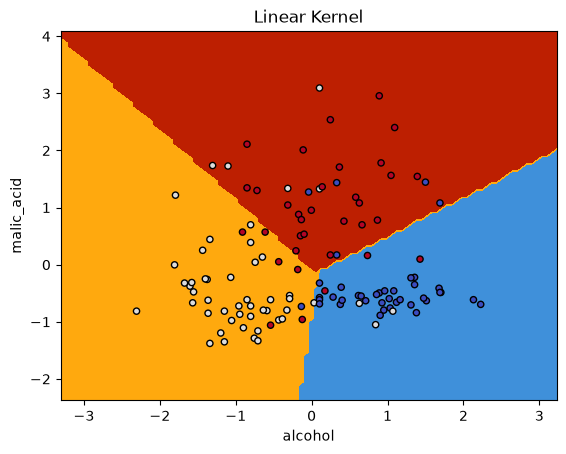

<Figure size 800x600 with 0 Axes>

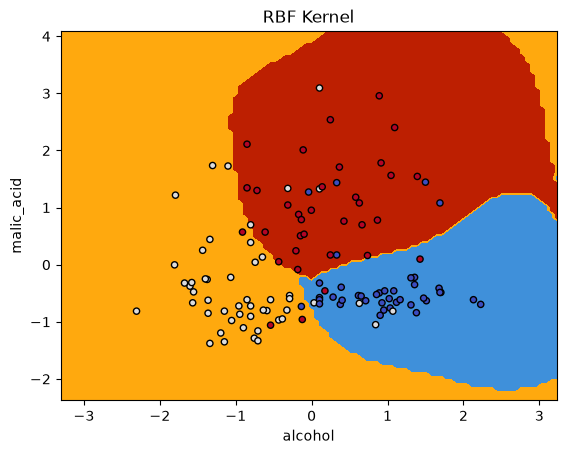

In [54]:
# plot the decision boundary for the linear kernel and rbf kernel
plt.figure(figsize=(8, 6))
DecisionBoundaryDisplay.from_estimator(
    svc_linear, 
    X_train, 
    response_method="predict", 
    xlabel=feature_x, 
    ylabel=feature_y,
)
plt.scatter(
    X_train[:, 0], 
    X_train[:, 1], 
    c=y_train, 
    cmap=plt.cm.coolwarm, 
    s=20, 
    edgecolor="k"
)
plt.title("Linear Kernel")
plt.show()

plt.figure(figsize=(8, 6))
DecisionBoundaryDisplay.from_estimator(
    svc_rbf, X_train, 
    response_method="predict", 
    xlabel=feature_x, 
    ylabel=feature_y,
)
plt.scatter(
    X_train[:, 0], 
    X_train[:, 1], 
    c=y_train, 
    cmap=plt.cm.coolwarm, 
    s=20, edgecolor="k"
)
plt.title("RBF Kernel")
plt.show()


## Comparing all kernel types

Wine has 3 classes (multi-class), so we can't rely purely on a linear boundary in 2D. Let's compare all four kernel types (`linear`, `rbf`, `poly`, `sigmoid`).

In [55]:
# train one SVC per kernel, all with the default C=1.0
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
svc_models = {}

for k in kernels:
    svc_models[k] = SVC(kernel=k, C=1.0, random_state=42).fit(X_train, y_train)

for k in kernels:
    print(f'{k:10s} train={svc_models[k].score(X_train, y_train):.4f}  test={svc_models[k].score(X_test, y_test):.4f}')

linear     train=0.8065  test=0.7407
rbf        train=0.8387  test=0.8148
poly       train=0.7661  test=0.7222
sigmoid    train=0.8065  test=0.7778


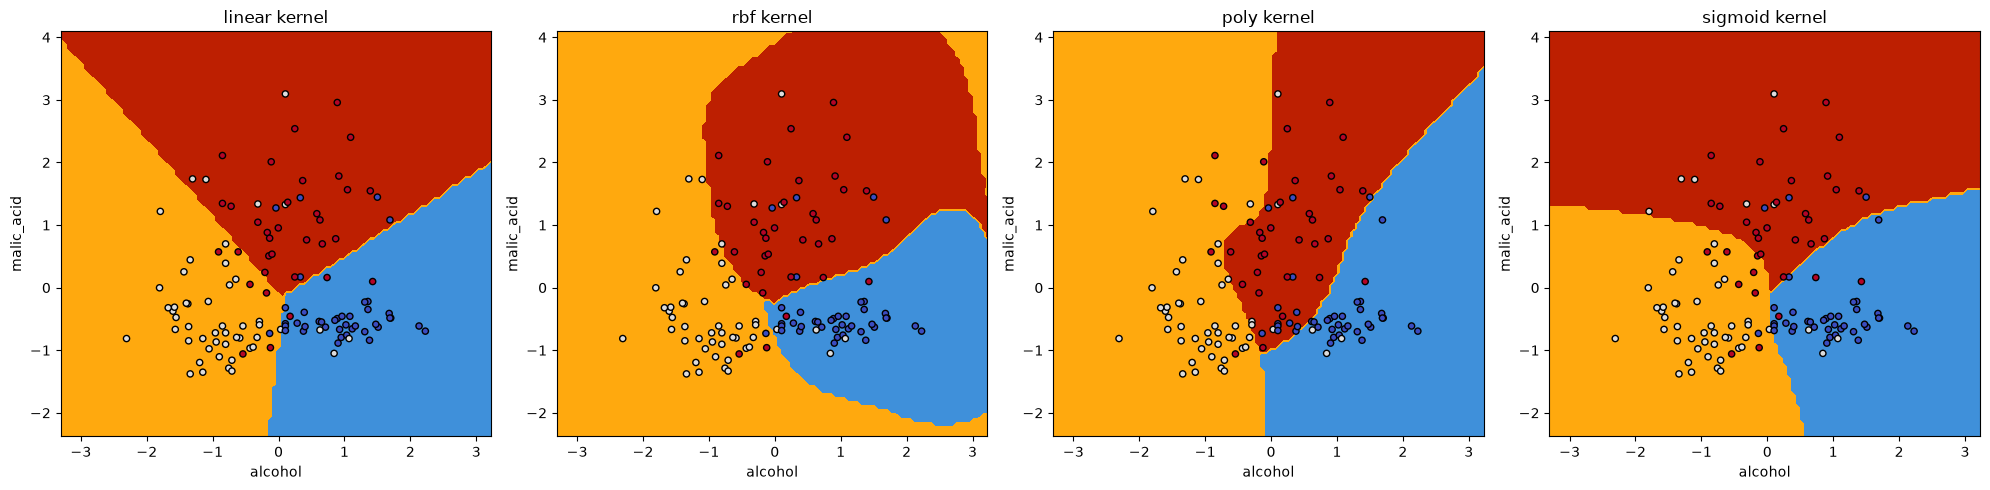

In [56]:
# plot the decision boundary for each kernel side by side
fig, axes = plt.subplots(1, len(kernels), figsize=(5 * len(kernels), 5))

for ax, k in zip(axes, kernels):
    DecisionBoundaryDisplay.from_estimator(
        svc_models[k], X_train, response_method='predict',
        xlabel=feature_x, ylabel=feature_y, ax=ax,
    )
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm, s=20, edgecolor='k')
    ax.set_title(f'{k} kernel')

plt.tight_layout()
plt.show()

## Tuning the regularization parameter C

C controls the trade-off between a wider margin (low C → more regularization, more misclassifications allowed) and fitting the training data tightly (high C → fewer misclassifications but risk of overfitting). Let's try several values of C for each kernel.

In [57]:
# grid of C values to try
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

results = []
for k in kernels:
    for C in C_values:
        model = SVC(kernel=k, C=C, random_state=42).fit(X_train, y_train)
        results.append({
            'kernel': k,
            'C': C,
            'train_acc': model.score(X_train, y_train),
            'test_acc': model.score(X_test, y_test),
        })

results_df = pd.DataFrame(results)
results_df

,kernel,C,train_acc,test_acc
0,linear,0.001,0.403226,0.388889
1,linear,0.010,0.677419,0.740741
2,linear,0.100,0.798387,0.759259
3,linear,1.000,0.806452,0.740741
4,linear,10.000,0.814516,0.740741
5,linear,100.000,0.814516,0.740741
6,linear,1000.000,0.814516,0.740741
7,rbf,0.001,0.403226,0.388889
8,rbf,0.010,0.403226,0.388889
9,rbf,0.100,0.822581,0.777778


In [58]:
# show test accuracy as a table: rows = C, columns = kernel
pivot_test = results_df.pivot_table(index='C', columns='kernel', values='test_acc')
pivot_test

# find the overall best kernel+C combo
best = results_df.loc[results_df['test_acc'].idxmax()]
print(f'\nBest on test set: kernel={best["kernel"]}, C={best["C"]}, test_acc={best["test_acc"]:.4f}')


Best on test set: kernel=rbf, C=10.0, test_acc=0.8333


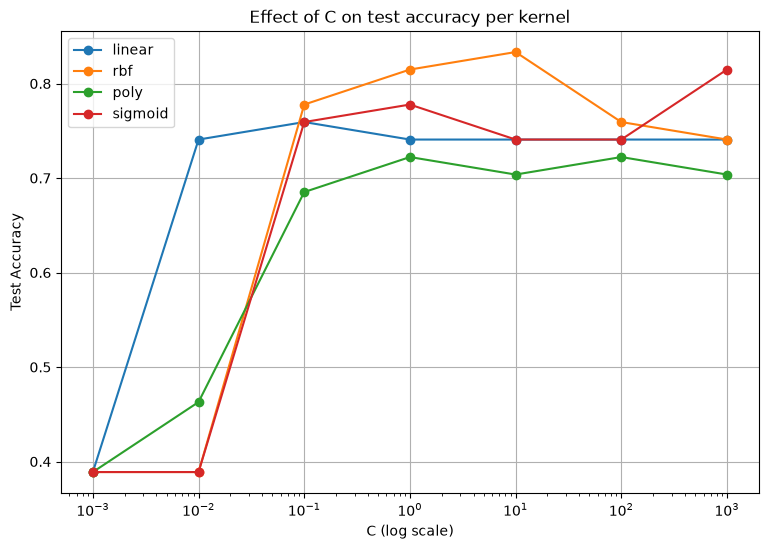

In [59]:
# plot test accuracy vs C for each kernel on a log scale
plt.figure(figsize=(9, 6))
for k in kernels:
    sub = results_df[results_df['kernel'] == k]
    plt.plot(sub['C'], sub['test_acc'], marker='o', label=k)

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Test Accuracy')
plt.title('Effect of C on test accuracy per kernel')
plt.legend()
plt.grid(True)
plt.show()